In [1]:
import pandas as pd
import numpy as np

In [ ]:
# PART 1: DATA LOADING + STRUCTURE

In [2]:
df = pd.read_csv(r"C:\Users\rasha\OneDrive\Desktop\Job 2026\Python\claim_data.csv")

In [4]:
df.head(10)

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome
0,0HO1FSN4AP,126528997,7936697103,08/07/2024,304,99231,A02.1,218,203,Self-Pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid
1,9U86CI2P5A,6986719948,1547160031,06/21/2024,348,99213,A16.5,216,206,Medicare,Paid,Pre-existing condition,Yes,Open,Denied
2,1QEU1AIDAU,1355108115,2611585318,07/04/2024,235,99213,A00.1,148,119,Commercial,Under Review,Duplicate claim,No,Denied,Denied
3,WH7XDS8CEO,9991055906,7167948632,05/26/2024,112,99215,A18.6,79,69,Medicare,Denied,Authorization not obtained,No,Partially Paid,Denied
4,M6OJEZ8KGI,7382167012,2140226267,07/16/2024,406,99238,A17.9,320,259,Medicare,Denied,Authorization not obtained,No,On Hold,Denied
5,NST1AJ3BG4,2460400334,5437847378,06/04/2024,272,99231,A02.1,202,176,Self-Pay,Paid,Patient eligibility issues,No,Pending,Partially Paid
6,G7C9QQKWHN,4996652383,1558663046,07/28/2024,358,99221,A01.9,249,202,Medicare,Denied,Incorrect billing information,No,Closed,Paid
7,GTGZLOTL2C,7437563222,5362322108,05/30/2024,365,99213,A07.8,252,205,Medicaid,Under Review,Patient eligibility issues,No,Open,Paid
8,TLU7MTJ63J,6675789567,1861061750,07/16/2024,126,99238,A05.4,109,108,Medicare,Denied,Authorization not obtained,No,Closed,Partially Paid
9,44K5PG8X8S,7933652528,2435590086,05/02/2024,342,99221,A09.9,258,251,Medicare,Paid,Patient eligibility issues,No,On Hold,Partially Paid


In [5]:
df.shape

(1000, 15)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Claim ID            1000 non-null   str           
 1   Provider ID         1000 non-null   int64         
 2   Patient ID          1000 non-null   int64         
 3   Date of Service     1000 non-null   datetime64[us]
 4   Billed Amount       1000 non-null   int64         
 5   Procedure Code      1000 non-null   int64         
 6   Diagnosis Code      1000 non-null   str           
 7   Allowed Amount      1000 non-null   int64         
 8   Paid Amount         1000 non-null   int64         
 9   Insurance Type      1000 non-null   str           
 10  Claim Status        1000 non-null   str           
 11  Reason Code         1000 non-null   str           
 12  Follow-up Required  1000 non-null   str           
 13  AR Status           1000 non-null   str           
 14  Outc

In [10]:
df.isnull().sum()

Claim ID              0
Provider ID           0
Patient ID            0
Date of Service       0
Billed Amount         0
Procedure Code        0
Diagnosis Code        0
Allowed Amount        0
Paid Amount           0
Insurance Type        0
Claim Status          0
Reason Code           0
Follow-up Required    0
AR Status             0
Outcome               0
dtype: int64

In [14]:
(df['Claim ID'].value_counts()>1).astype(int).sum() # no duplicates in claimid

0

In [15]:
import datetime

In [16]:
df['Date of Service'] = pd.to_datetime(df['Date of Service'])

In [ ]:
# PART 2: DATA QUALITY CHECKS

In [20]:
df.isnull().sum()*100.0/len(df)

Claim ID              0.0
Provider ID           0.0
Patient ID            0.0
Date of Service       0.0
Billed Amount         0.0
Procedure Code        0.0
Diagnosis Code        0.0
Allowed Amount        0.0
Paid Amount           0.0
Insurance Type        0.0
Claim Status          0.0
Reason Code           0.0
Follow-up Required    0.0
AR Status             0.0
Outcome               0.0
dtype: float64

In [23]:
# invalid claim ids  - not length 10
df['invalid_claims'] = df['Claim ID'].apply(lambda x : 1 if len(x) != 10 else 0)
df['invalid_claims'].sum()

0

In [25]:
(df['Patient ID'].value_counts()>1).astype(int).sum() # no duplicates

0

In [26]:
df[df['Billed Amount']<=0] # no negative charge amounts

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome,invalid_claims


In [27]:
df[df['Paid Amount']> df['Billed Amount']]

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome,invalid_claims


In [ ]:
# PART 3: DATA CLEANING

In [28]:
df.drop_duplicates(subset = ['Claim ID'])

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome,invalid_claims
0,0HO1FSN4AP,126528997,7936697103,2024-08-07,304,99231,A02.1,218,203,Self-Pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid,0
1,9U86CI2P5A,6986719948,1547160031,2024-06-21,348,99213,A16.5,216,206,Medicare,Paid,Pre-existing condition,Yes,Open,Denied,0
2,1QEU1AIDAU,1355108115,2611585318,2024-07-04,235,99213,A00.1,148,119,Commercial,Under Review,Duplicate claim,No,Denied,Denied,0
3,WH7XDS8CEO,9991055906,7167948632,2024-05-26,112,99215,A18.6,79,69,Medicare,Denied,Authorization not obtained,No,Partially Paid,Denied,0
4,M6OJEZ8KGI,7382167012,2140226267,2024-07-16,406,99238,A17.9,320,259,Medicare,Denied,Authorization not obtained,No,On Hold,Denied,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0B0TP89BQF,7640195037,6836887959,2024-05-30,307,99238,A08.8,231,213,Commercial,Paid,Service not covered,No,Pending,Partially Paid,0
996,VVROAPZFFA,3378390045,8592277150,2024-06-23,150,99215,A02.8,105,99,Medicare,Paid,Lack of medical necessity,Yes,Closed,Partially Paid,0
997,Q9J55DIMLR,2766789913,9757787667,2024-07-07,128,99213,A02.2,83,75,Medicare,Paid,Authorization not obtained,Yes,Partially Paid,Paid,0
998,531HVTDM18,1335890669,1995402912,2024-05-14,178,99215,A08.2,122,103,Medicaid,Under Review,Patient eligibility issues,Yes,On Hold,Denied,0


In [29]:
df['Insurance Type'] = df['Insurance Type'].fillna('Unknown')

In [30]:
df['Reason Code'] = df['Reason Code'].fillna('No Reason Provided')

In [32]:
df['Billed Amount']  = df['Billed Amount'].replace("$", "")
df['Billed Amount']  = df['Billed Amount'].replace(",", "")

In [33]:
df['Billed Amount'] = df['Billed Amount'].astype(int)

In [35]:
df['Date of Service'].max()

Timestamp('2024-09-20 00:00:00')

In [37]:
from datetime import date
df['futuredateofservice'] = df['Date of Service']>date.today()

TypeError: Invalid comparison between dtype=datetime64[us] and date

In [39]:
df['Insurance Type'] = df['Insurance Type'].apply(lambda x : x.lower())

In [43]:
df['Insurance Type'].value_counts()

Insurance Type
commercial    259
medicaid      259
self-pay      249
medicare      233
Name: count, dtype: int64

In [48]:
df[df['Claim Status'] != 'Null']

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome,invalid_claims
0,0HO1FSN4AP,126528997,7936697103,2024-08-07,304,99231,A02.1,218,203,self-pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid,0
1,9U86CI2P5A,6986719948,1547160031,2024-06-21,348,99213,A16.5,216,206,medicare,Paid,Pre-existing condition,Yes,Open,Denied,0
2,1QEU1AIDAU,1355108115,2611585318,2024-07-04,235,99213,A00.1,148,119,commercial,Under Review,Duplicate claim,No,Denied,Denied,0
3,WH7XDS8CEO,9991055906,7167948632,2024-05-26,112,99215,A18.6,79,69,medicare,Denied,Authorization not obtained,No,Partially Paid,Denied,0
4,M6OJEZ8KGI,7382167012,2140226267,2024-07-16,406,99238,A17.9,320,259,medicare,Denied,Authorization not obtained,No,On Hold,Denied,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0B0TP89BQF,7640195037,6836887959,2024-05-30,307,99238,A08.8,231,213,commercial,Paid,Service not covered,No,Pending,Partially Paid,0
996,VVROAPZFFA,3378390045,8592277150,2024-06-23,150,99215,A02.8,105,99,medicare,Paid,Lack of medical necessity,Yes,Closed,Partially Paid,0
997,Q9J55DIMLR,2766789913,9757787667,2024-07-07,128,99213,A02.2,83,75,medicare,Paid,Authorization not obtained,Yes,Partially Paid,Paid,0
998,531HVTDM18,1335890669,1995402912,2024-05-14,178,99215,A08.2,122,103,medicaid,Under Review,Patient eligibility issues,Yes,On Hold,Denied,0


In [ ]:
# PART 4: DATA VALIDATION RULES

In [ ]:
# Charge Amount must always be ≥ Paid Amount.

In [51]:
df[df['Billed Amount'] >= df['Paid Amount']]

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome,invalid_claims
0,0HO1FSN4AP,126528997,7936697103,2024-08-07,304,99231,A02.1,218,203,self-pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid,0
1,9U86CI2P5A,6986719948,1547160031,2024-06-21,348,99213,A16.5,216,206,medicare,Paid,Pre-existing condition,Yes,Open,Denied,0
2,1QEU1AIDAU,1355108115,2611585318,2024-07-04,235,99213,A00.1,148,119,commercial,Under Review,Duplicate claim,No,Denied,Denied,0
3,WH7XDS8CEO,9991055906,7167948632,2024-05-26,112,99215,A18.6,79,69,medicare,Denied,Authorization not obtained,No,Partially Paid,Denied,0
4,M6OJEZ8KGI,7382167012,2140226267,2024-07-16,406,99238,A17.9,320,259,medicare,Denied,Authorization not obtained,No,On Hold,Denied,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0B0TP89BQF,7640195037,6836887959,2024-05-30,307,99238,A08.8,231,213,commercial,Paid,Service not covered,No,Pending,Partially Paid,0
996,VVROAPZFFA,3378390045,8592277150,2024-06-23,150,99215,A02.8,105,99,medicare,Paid,Lack of medical necessity,Yes,Closed,Partially Paid,0
997,Q9J55DIMLR,2766789913,9757787667,2024-07-07,128,99213,A02.2,83,75,medicare,Paid,Authorization not obtained,Yes,Partially Paid,Paid,0
998,531HVTDM18,1335890669,1995402912,2024-05-14,178,99215,A08.2,122,103,medicaid,Under Review,Patient eligibility issues,Yes,On Hold,Denied,0


In [52]:
df[df['Paid Amount'] < 0]

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome,invalid_claims


In [53]:
df['Claim Status'].value_counts()

Claim Status
Under Review    338
Paid            334
Denied          328
Name: count, dtype: int64

In [54]:
df['Follow-up Required'].value_counts()

Follow-up Required
Yes    522
No     478
Name: count, dtype: int64

In [59]:
df['AR Status'].value_counts()

AR Status
Partially Paid    184
On Hold           177
Pending           162
Open              160
Closed            160
Denied            157
Name: count, dtype: int64

In [55]:
df.columns

Index(['Claim ID', 'Provider ID', 'Patient ID', 'Date of Service',
       'Billed Amount', 'Procedure Code', 'Diagnosis Code', 'Allowed Amount',
       'Paid Amount', 'Insurance Type', 'Claim Status', 'Reason Code',
       'Follow-up Required', 'AR Status', 'Outcome', 'invalid_claims'],
      dtype='str')

In [56]:
df['Procedure Code'].unique()

array([99231, 99213, 99215, 99238, 99221, 99223, 99233, 99214, 99222,
       99232], dtype=int64)

In [57]:
df['Diagnosis Code'].unique()

<StringArray>
['A02.1', 'A16.5', 'A00.1', 'A18.6', 'A17.9', 'A01.9', 'A07.8', 'A05.4',
 'A09.9', 'A03.9', 'A02.2', 'A06.0', 'A07.0', 'A03.3', 'A00.9', 'A05.0',
 'A04.2', 'A16.9', 'A08.1', 'A06.8', 'A16.3', 'A18.1', 'A19.8', 'A16.8',
 'A18.3', 'A18.7', 'A04.6', 'A05.7', 'A06.3', 'A16.1', 'A08.0', 'A04.7',
 'A18.4', 'A09.0', 'A06.7', 'A05.2', 'A02.0', 'A17.8', 'A15.0', 'A06.5',
 'A01.4', 'A01.3', 'A08.3', 'A00.0', 'A07.2', 'A01.6', 'A18.8', 'A19.1',
 'A03.8', 'A17.0', 'A19.9', 'A02.4', 'A05.1', 'A04.1', 'A07.1', 'A04.0',
 'A04.3', 'A02.9', 'A19.0', 'A06.6', 'A16.4', 'A05.6', 'A07.9', 'A01.1',
 'A04.5', 'A18.0', 'A18.9', 'A08.8', 'A03.1', 'A16.2', 'A02.3', 'A18.5',
 'A07.3', 'A17.1', 'A16.0', 'A02.8', 'A08.2', 'A01.0', 'A04.8', 'A18.2',
 'A06.9', 'A01.2', 'A05.9', 'A01.5', 'A06.4', 'A15.9', 'A05.3', 'A03.2',
 'A08.9', 'A06.2', 'A06.1', 'A04.4', 'A05.5', 'A16.7', 'A05.8', 'A15.1',
 'A04.9', 'A03.0', 'A08.4', 'A08.5']
Length: 100, dtype: str

In [116]:
# pattern validation
pattern  = "[A-Z][0-9]{2}(\.[0-9]+)?$"
# ? makes everthyig optional in round brackets, for decimal we need \ to make it actual dot, not anything
# $ end of pattern
df['valid_code'] = df['Diagnosis Code'].str.match(pattern)
df.head()

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,...,Reason Code,Follow-up Required,AR Status,Outcome,invalid_claims,recovery_ratio,claim_age,claimagebucket,highvalueclaimflag,valid_code
0,0HO1FSN4AP,126528997,7936697103,2024-08-07,304,99231,A02.1,218,203,self-pay,...,Incorrect billing information,Yes,Pending,Partially Paid,0,0.667763,617,"(365, 730]",1,True
1,9U86CI2P5A,6986719948,1547160031,2024-06-21,348,99213,A16.5,216,206,medicare,...,Pre-existing condition,Yes,Open,Denied,0,0.591954,664,"(365, 730]",1,True
2,1QEU1AIDAU,1355108115,2611585318,2024-07-04,235,99213,A00.1,148,119,commercial,...,Duplicate claim,No,Denied,Denied,0,0.506383,651,"(365, 730]",0,True
3,WH7XDS8CEO,9991055906,7167948632,2024-05-26,112,99215,A18.6,79,69,medicare,...,Authorization not obtained,No,Partially Paid,Denied,0,0.616071,690,"(365, 730]",0,True
4,M6OJEZ8KGI,7382167012,2140226267,2024-07-16,406,99238,A17.9,320,259,medicare,...,Authorization not obtained,No,On Hold,Denied,0,0.637931,639,"(365, 730]",1,True


In [61]:
df[(df['AR Status'] != 'Closed') & (df['Claim Status'] == 'Paid')]

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome,invalid_claims
0,0HO1FSN4AP,126528997,7936697103,2024-08-07,304,99231,A02.1,218,203,self-pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid,0
1,9U86CI2P5A,6986719948,1547160031,2024-06-21,348,99213,A16.5,216,206,medicare,Paid,Pre-existing condition,Yes,Open,Denied,0
5,NST1AJ3BG4,2460400334,5437847378,2024-06-04,272,99231,A02.1,202,176,self-pay,Paid,Patient eligibility issues,No,Pending,Partially Paid,0
9,44K5PG8X8S,7933652528,2435590086,2024-05-02,342,99221,A09.9,258,251,medicare,Paid,Patient eligibility issues,No,On Hold,Partially Paid,0
14,2VO26C5QLH,1637431064,651880351,2024-08-10,493,99233,A07.0,366,360,medicaid,Paid,Pre-existing condition,No,Partially Paid,Paid,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,KGZKX8JZID,3396848878,5610783650,2024-09-14,350,99238,A16.2,261,242,self-pay,Paid,Incorrect billing information,No,Partially Paid,Paid,0
989,64BXHI5GEZ,6596054863,6385714360,2024-07-02,368,99231,A18.4,319,304,commercial,Paid,Duplicate claim,Yes,Open,Denied,0
995,0B0TP89BQF,7640195037,6836887959,2024-05-30,307,99238,A08.8,231,213,commercial,Paid,Service not covered,No,Pending,Partially Paid,0
997,Q9J55DIMLR,2766789913,9757787667,2024-07-07,128,99213,A02.2,83,75,medicare,Paid,Authorization not obtained,Yes,Partially Paid,Paid,0


In [58]:
df.columns

Index(['Claim ID', 'Provider ID', 'Patient ID', 'Date of Service',
       'Billed Amount', 'Procedure Code', 'Diagnosis Code', 'Allowed Amount',
       'Paid Amount', 'Insurance Type', 'Claim Status', 'Reason Code',
       'Follow-up Required', 'AR Status', 'Outcome', 'invalid_claims'],
      dtype='str')

In [ ]:
# PART 5: FEATURE ENGINEERING

In [62]:
df['recovery_ratio'] = df['Paid Amount'] / df['Billed Amount']

In [71]:
df['claim_age'] = (pd.Timestamp.today()- df['Date of Service']).dt.days

In [83]:
bins = [0,30,90, 180, 365, 730 , 1000]
df['claimagebucket'] = pd.cut(df['claim_age'], bins = bins)

In [84]:
df.head(2)

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome,invalid_claims,recovery_ratio,claim_age,claimagebucket
0,0HO1FSN4AP,126528997,7936697103,2024-08-07,304,99231,A02.1,218,203,self-pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid,0,0.667763,617,"(365, 730]"
1,9U86CI2P5A,6986719948,1547160031,2024-06-21,348,99213,A16.5,216,206,medicare,Paid,Pre-existing condition,Yes,Open,Denied,0,0.591954,664,"(365, 730]"


In [89]:
df['highvalueclaimflag'] = (df['Billed Amount'] > 300).astype(int)

In [ ]:
# PART 6: INSIGHTS / ANALYSIS

In [92]:
df.groupby('Provider ID')['Billed Amount'].sum().sort_values(ascending = False).head(5)

Provider ID
2577958286    500
2962998721    499
5081779992    499
8076796115    499
4509814818    498
Name: Billed Amount, dtype: int32

In [99]:
r = df.groupby('Insurance Type')['Outcome'].value_counts().reset_index().sort_values(by = ['Insurance Type'], ascending = False)

In [100]:
r

,Insurance Type,Outcome,count
9,self-pay,Denied,88
10,self-pay,Partially Paid,87
11,self-pay,Paid,74
6,medicare,Paid,86
7,medicare,Denied,77
8,medicare,Partially Paid,70
3,medicaid,Paid,102
4,medicaid,Partially Paid,79
5,medicaid,Denied,78
0,commercial,Paid,95


In [107]:
r['groupsum'] = r.groupby('Insurance Type')['count'].transform('sum')
r['rate'] = r['count']*100.0 / r['groupsum']
denialpercentage = r[r['Outcome'] =='Denied']

In [110]:
import seaborn as sns

In [114]:
denialpercentage

,Insurance Type,Outcome,count,groupsum,rate
9,self-pay,Denied,88,249,35.341365
7,medicare,Denied,77,233,33.047210
5,medicaid,Denied,78,259,30.115830
1,commercial,Denied,88,259,33.976834


<Axes: xlabel='Insurance Type', ylabel='rate'>

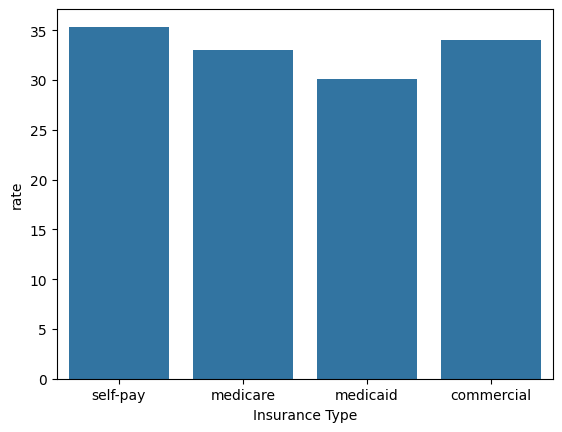

In [115]:
sns.barplot(x = denialpercentage['Insurance Type'],  y = denialpercentage['rate'])